# Exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Basic Inspection

In [2]:
df = pd.read_csv("../data/baltic_prices.csv", index_col="Date", parse_dates=True)
df.head()

,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2021-01-04,0.610417,1.079082,1.079360,1.088082,NaN,0.623248,15.258244,0.491755,4.814266,15.360378,1.918030,6.853395,1.046326,3.00,0.705
2021-01-05,0.605994,1.063841,1.096630,1.097165,NaN,0.627168,15.258244,0.493590,5.029830,15.251439,2.035093,7.025807,1.037228,2.96,0.705
2021-01-06,0.610417,1.066889,1.113899,1.135311,NaN,0.623248,15.337713,0.493590,5.119648,15.251439,2.062107,7.169484,1.056436,2.96,0.705
2021-01-07,0.623687,1.060793,1.122534,1.131678,NaN,0.627168,15.337713,0.510104,4.940012,15.251439,2.089122,7.169484,1.046832,3.00,0.705
2021-01-08,0.641381,1.042504,1.122534,1.122596,NaN,0.627168,15.417183,0.530288,4.922048,15.578258,2.116136,7.155117,1.056436,2.98,0.700


In [3]:
df.tail()

,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2026-03-27,1.58,3.47,1.505,2.230,1.380,1.23,19.700001,1.050,5.68,21.400000,3.565,27.049999,0.580,0.930,0.92
2026-03-30,1.54,3.52,1.505,2.230,1.372,1.23,19.700001,1.045,5.68,21.350000,3.565,27.049999,0.580,0.918,0.92
2026-03-31,1.55,3.53,1.500,2.235,1.386,1.23,19.799999,1.050,5.60,21.350000,3.550,27.100000,0.580,0.900,0.92
2026-04-01,1.58,3.59,1.505,2.245,1.410,1.23,19.650000,1.050,5.62,21.350000,3.550,27.250000,0.617,0.900,0.92
2026-04-02,1.58,3.61,1.500,2.250,1.406,1.23,19.850000,1.055,5.60,21.549999,3.550,27.000000,0.609,0.882,0.92


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1331 entries, 2021-01-04 to 2026-04-02
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AKO1L.VS  1307 non-null   float64
 1   APG1L.VS  1307 non-null   float64
 2   ARC1T.TL  1319 non-null   float64
 3   CPA1T.TL  1319 non-null   float64
 4   DGR1R.RG  1103 non-null   float64
 5   EEG1T.TL  1319 non-null   float64
 6   EFT1T.TL  1319 non-null   float64
 7   GRG1L.VS  1307 non-null   float64
 8   HAE1T.TL  1319 non-null   float64
 9   IGN1L.VS  1307 non-null   float64
 10  LHV1T.TL  1319 non-null   float64
 11  MRK1T.TL  1319 non-null   float64
 12  NCN1T.TL  1319 non-null   float64
 13  NTU1L.VS  1307 non-null   float64
 14  PKG1T.TL  1319 non-null   float64
dtypes: float64(15)
memory usage: 166.4 KB


In [5]:
print(f"Shape: {df.shape}")  # expect ~1300 rows × 15 columns
print()
print(df.dtypes)
print()
print(f"Date range: {df.index.min()} to {df.index.max()}")

Shape: (1331, 15)

AKO1L.VS    float64
APG1L.VS    float64
ARC1T.TL    float64
CPA1T.TL    float64
DGR1R.RG    float64
EEG1T.TL    float64
EFT1T.TL    float64
GRG1L.VS    float64
HAE1T.TL    float64
IGN1L.VS    float64
LHV1T.TL    float64
MRK1T.TL    float64
NCN1T.TL    float64
NTU1L.VS    float64
PKG1T.TL    float64
dtype: object

Date range: 2021-01-04 00:00:00 to 2026-04-02 00:00:00


## 2. Data Quality

In [6]:

df.loc["2023"].head(5)

,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2023-01-02,1.215163,1.63152,1.663738,2.268984,1.200976,1.324571,16.561081,0.594817,4.676728,15.607603,3.117248,11.675851,0.678,2.970,0.602
2023-01-03,1.228765,1.63918,1.663738,2.296543,1.204213,1.315885,16.561081,0.601519,4.676728,15.656842,3.117248,11.773967,0.685,2.970,0.600
2023-01-04,1.251436,1.64684,1.660098,2.272658,1.207451,1.307200,16.561081,0.608222,4.751555,15.607603,3.135803,11.773967,0.680,2.950,0.596
2023-01-05,1.278641,1.63918,1.638255,2.274496,1.209069,1.311543,16.561081,0.609897,4.676728,15.607603,3.145081,11.806672,0.695,2.943,0.596
2023-01-06,1.269573,1.65450,1.638255,2.261635,1.210688,1.320228,16.561081,0.611573,4.742202,15.607603,3.140442,11.855731,0.700,2.942,0.600


### 2a. Missing Values

In [7]:
nan_counts = df.isnull().sum()
nan_pct = df.isnull().sum() / len(df) * 100

missing = pd.DataFrame({"NaN count": nan_counts, "NaN %": nan_pct.round(2)})
print(missing.sort_values("NaN %", ascending=False))
print()
flagged = nan_pct[nan_pct > 5].index.tolist()
print(f"Tickers with >5% missing: {flagged}")

          NaN count  NaN %
DGR1R.RG        228  17.13
APG1L.VS         24   1.80
AKO1L.VS         24   1.80
IGN1L.VS         24   1.80
NTU1L.VS         24   1.80
GRG1L.VS         24   1.80
ARC1T.TL         12   0.90
EFT1T.TL         12   0.90
EEG1T.TL         12   0.90
CPA1T.TL         12   0.90
HAE1T.TL         12   0.90
LHV1T.TL         12   0.90
MRK1T.TL         12   0.90
NCN1T.TL         12   0.90
PKG1T.TL         12   0.90

Tickers with >5% missing: ['DGR1R.RG']


### 2b. Missing Value Pattern

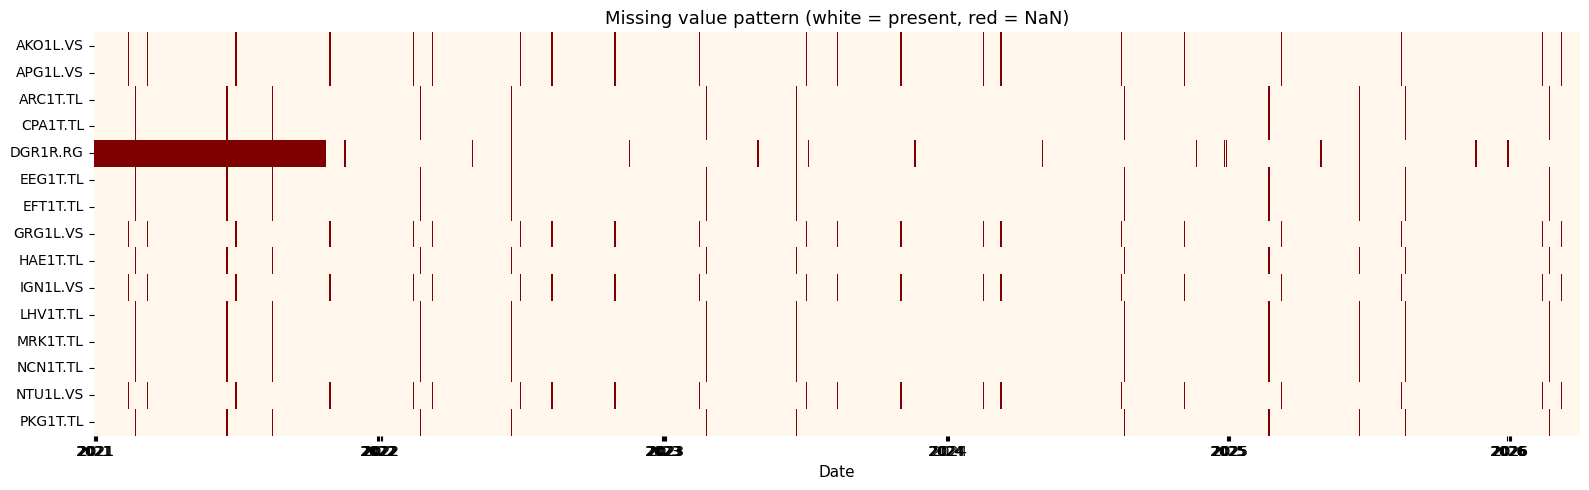

DGR1R.RG: first valid date = 2021-10-27 00:00:00


In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, ax=ax, cmap="OrRd")
ax.set_title("Missing value pattern (white = present, red = NaN)", fontsize=13)
ax.set_xlabel("Date", fontsize=11)
ax.tick_params(axis="y", labelsize=10)

# Show only yearly x-tick labels instead of every date
yearly_ticks = [i for i, d in enumerate(df.index) if d.month == 1 and d.day <= 7]
ax.set_xticks(yearly_ticks)
ax.set_xticklabels([df.index[i].year for i in yearly_ticks], rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Are NaNs clustered at the start (late listing) or scattered?
for ticker in flagged:
    first_valid = df[ticker].first_valid_index()
    print(f"{ticker}: first valid date = {first_valid}")

### 2c. Trading Calendar Gaps

In [9]:
gap_counts = df.index.to_series().diff().dt.days.value_counts().sort_index()
print("Days between consecutive trading dates:")
print(gap_counts)
print()
# Most gaps should be 1 (consecutive days) or 3 (Friday→Monday)
unusual = gap_counts[gap_counts.index > 3]
if not unusual.empty:
    print("Unusual gaps (>3 days):")
    print(unusual)

Days between consecutive trading dates:
Date
1.0    1045
2.0       9
3.0     261
4.0       8
5.0       6
6.0       1
Name: count, dtype: int64

Unusual gaps (>3 days):
Date
4.0    8
5.0    6
6.0    1
Name: count, dtype: int64


### 2d. Stale Prices (Flat Lines)

In [10]:
stale = (df.diff() == 0).sum()
stale_pct = (stale / len(df) * 100).round(2)

stale_df = pd.DataFrame({"Zero-change days": stale, "% of days": stale_pct})
print(stale_df.sort_values("Zero-change days", ascending=False))
print()
# Flag tickers with high stale rate — signals illiquid/thinly traded stock
stale_flagged = stale_pct[stale_pct > 20].index.tolist()
print(f"Tickers with >20% stale days: {stale_flagged}")

          Zero-change days  % of days
EFT1T.TL               456      34.26
PKG1T.TL               357      26.82
APG1L.VS               333      25.02
EEG1T.TL               330      24.79
GRG1L.VS               320      24.04
AKO1L.VS               311      23.37
IGN1L.VS               285      21.41
DGR1R.RG               281      21.11
ARC1T.TL               255      19.16
NCN1T.TL               239      17.96
HAE1T.TL               216      16.23
NTU1L.VS               195      14.65
MRK1T.TL               188      14.12
LHV1T.TL               162      12.17
CPA1T.TL               157      11.80

Tickers with >20% stale days: ['AKO1L.VS', 'APG1L.VS', 'DGR1R.RG', 'EEG1T.TL', 'EFT1T.TL', 'GRG1L.VS', 'IGN1L.VS', 'PKG1T.TL']


In [11]:
df.diff().head(20)

,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,-0.004423,-0.015241,0.017270,0.009082,NaN,0.003920,0.000000,0.001835,0.215563,-0.108939,0.117063,0.172411,-0.009099,-0.04,0.000
2021-01-06,0.004423,0.003048,0.017270,0.038146,NaN,-0.003920,0.079470,0.000000,0.089818,0.000000,0.027014,0.143677,0.019208,0.00,0.000
2021-01-07,0.013270,-0.006096,0.008635,-0.003633,NaN,0.003920,0.000000,0.016514,-0.179636,0.000000,0.027015,0.000000,-0.009604,0.04,0.000
2021-01-08,0.017693,-0.018289,0.000000,-0.009083,NaN,0.000000,0.079470,0.020184,-0.017963,0.326818,0.027014,-0.014367,0.009604,-0.02,-0.005
2021-01-11,0.013270,0.024386,0.008635,0.001817,NaN,0.000000,0.079470,0.005505,0.000000,0.290503,-0.036019,0.000000,-0.009604,-0.02,0.000
2021-01-12,0.008847,-0.003048,0.017270,-0.009083,NaN,0.023519,-0.079470,0.014679,0.000000,0.000000,-0.018010,0.064655,0.000000,0.02,0.000
2021-01-13,0.008847,-0.012193,-0.017270,-0.021798,NaN,-0.007840,0.000000,-0.009174,-0.035927,0.036311,-0.027014,0.071837,0.000000,-0.02,-0.005
2021-01-14,0.000000,-0.006096,0.000000,0.012716,NaN,0.027439,0.238411,0.000000,-0.071855,0.036315,0.018010,0.071839,0.000000,0.02,0.005


## 3. Price & Return Series

### 3a. Compute Returns

In [12]:
daily_returns = df.pct_change().dropna(how="all")
monthly_prices = df.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna(how="all")

print(f"Daily returns:   {daily_returns.shape}  ({daily_returns.index[0].date()} → {daily_returns.index[-1].date()})")
print(f"Monthly returns: {monthly_returns.shape}  ({monthly_returns.index[0].date()} → {monthly_returns.index[-1].date()})")
monthly_returns.head()

Daily returns:   (1330, 15)  (2021-01-05 → 2026-04-02)
Monthly returns: (63, 15)  (2021-02-28 → 2026-04-30)


,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2021-02-28,0.033557,-0.011696,0.000000,0.367480,NaN,-0.044944,0.005155,0.051383,0.316151,-0.045872,-0.069388,0.154929,0.045872,0.101449,0.101449
2021-03-31,0.006493,0.005917,-0.036232,0.127230,NaN,0.000000,-0.005128,0.011278,0.083551,-0.021635,0.013158,0.101626,0.149123,0.177632,-0.052632
2021-04-30,0.014194,0.082353,0.315790,0.149789,NaN,0.138824,0.108247,0.219331,0.004819,0.021264,0.085050,0.188192,0.133588,0.268156,0.027778
2021-05-31,0.027990,0.076087,0.217143,-0.034404,NaN,-0.053719,-0.009302,0.184076,-0.009918,0.047030,0.008081,-0.008696,-0.063973,0.145374,0.500000
2021-06-30,0.014851,0.015152,0.071286,0.045131,NaN,0.085153,0.065416,0.079823,0.009877,-0.018913,-0.002004,0.009190,0.056219,-0.086538,-0.072072


### 3b. Normalized Price Chart (Base 100)

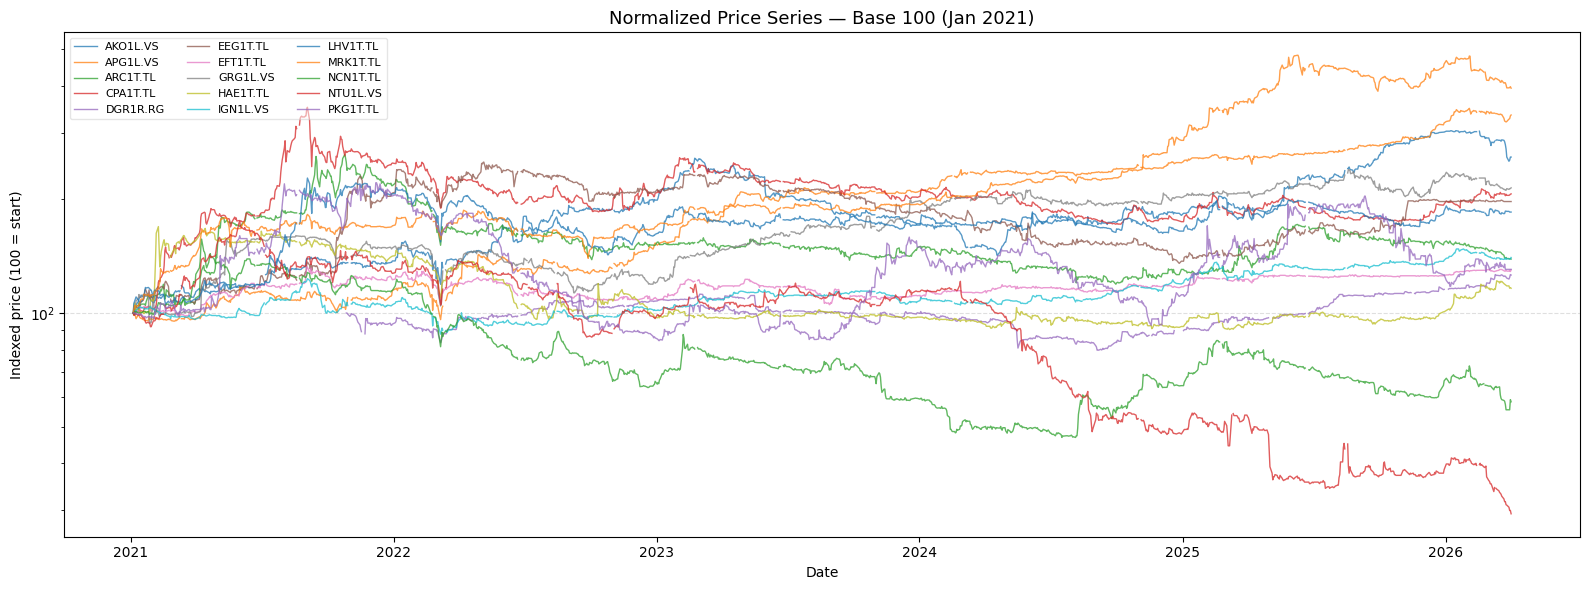

Top 5 performers (total % return):
MRK1T.TL    294.0
APG1L.VS    234.5
AKO1L.VS    158.8
GRG1L.VS    114.5
CPA1T.TL    106.8
Name: 2026-04-02 00:00:00, dtype: float64

Bottom 5 performers:
EFT1T.TL    30.1
DGR1R.RG    26.1
HAE1T.TL    16.3
NCN1T.TL   -41.8
NTU1L.VS   -70.6
Name: 2026-04-02 00:00:00, dtype: float64


In [13]:
# backward fill to handle NaNs at start, then index to 100 at
normalized = df.div(df.bfill().iloc[0]) * 100  

fig, ax = plt.subplots(figsize=(16, 6))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], linewidth=1, alpha=0.75, label=col)

ax.set_title("Normalized Price Series — Base 100 (Jan 2021)", fontsize=13)
ax.set_ylabel("Indexed price (100 = start)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", ncol=3, fontsize=8, framealpha=0.5)
ax.set_yscale("log")  # log scale keeps fast movers from drowning out slow ones
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Top/bottom performers
total_return = (normalized.iloc[-1] - 100).sort_values(ascending=False)
print("Top 5 performers (total % return):")
print(total_return.head(5).round(1))
print("\nBottom 5 performers:")
print(total_return.tail(5).round(1))

### 3c. Individual Price Series (Small Multiples)

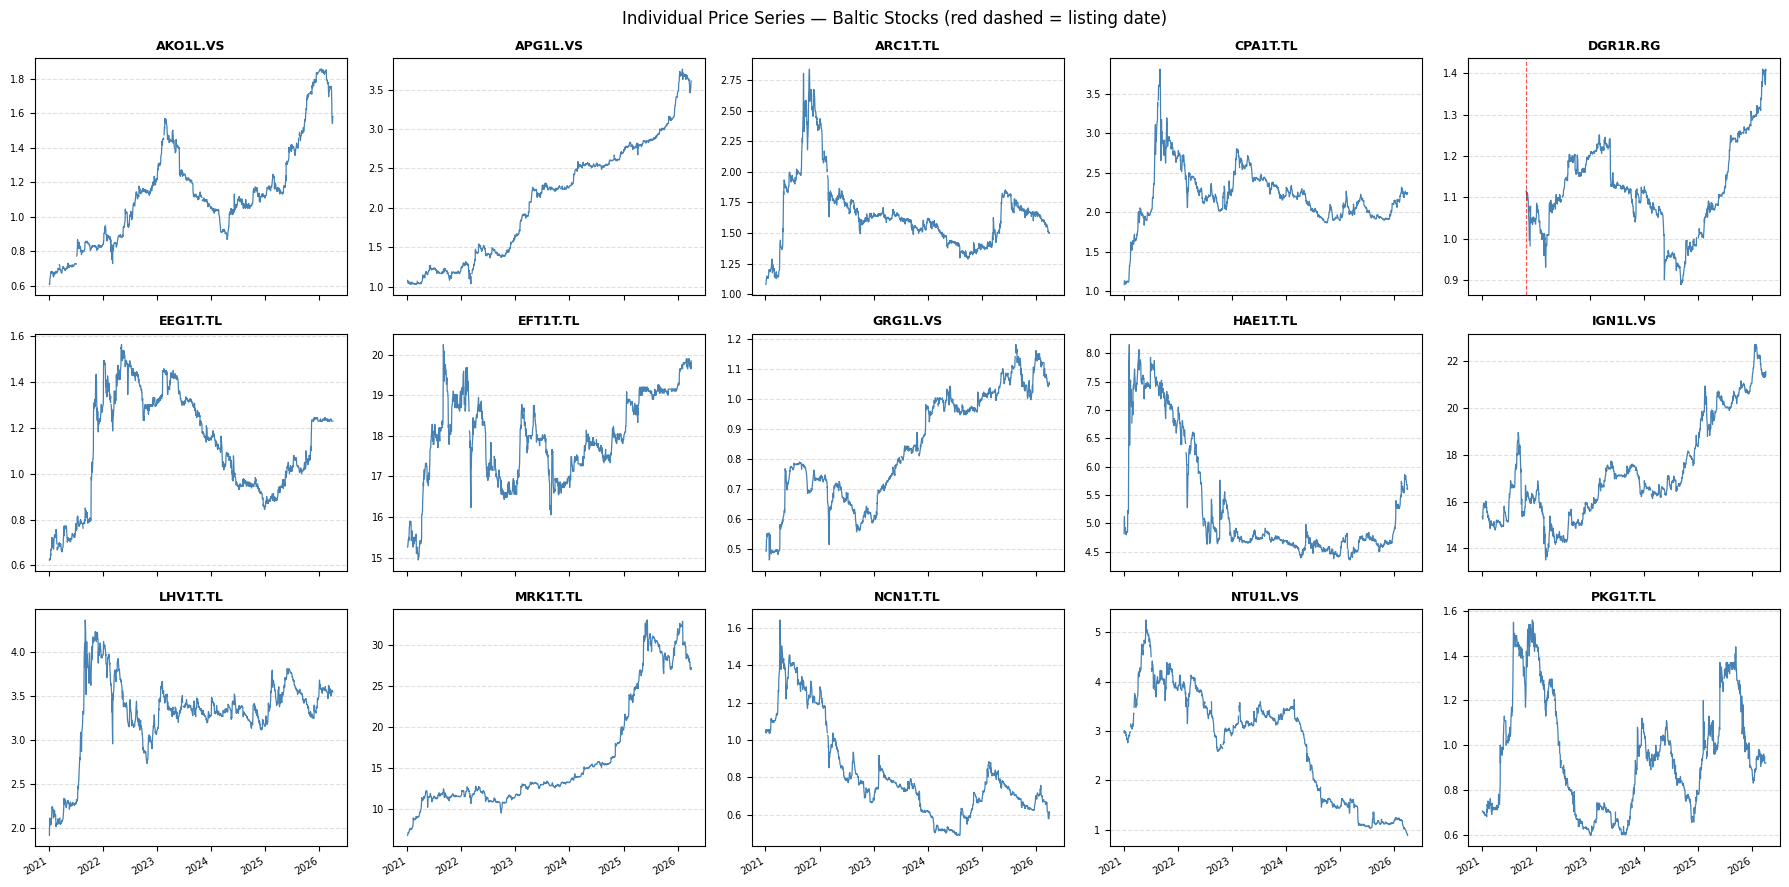

In [14]:
tickers = df.columns.tolist()
fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    ax.plot(df.index, df[ticker], linewidth=0.9, color="steelblue")
    ax.set_title(ticker, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    # Mark first valid date if ticker has leading NaNs
    first_valid = df[ticker].first_valid_index()
    if first_valid != df.index[0]:
        ax.axvline(first_valid, color="red", linewidth=0.8, linestyle="--", alpha=0.7)

fig.suptitle("Individual Price Series — Baltic Stocks (red dashed = listing date)", fontsize=12)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 4. Return Distributions

### 4a. Summary Statistics (Daily Returns)

In [15]:
ann_return = daily_returns.mean() * 252
ann_vol = daily_returns.std() * np.sqrt(252)
sharpe = ann_return / ann_vol

summary = pd.DataFrame({
    "Ann. Return": ann_return.round(4),
    "Ann. Vol":    ann_vol.round(4),
    "Sharpe":      sharpe.round(2),
    "Min Daily Return":         daily_returns.min().round(4),
    "Max Daily Return":         daily_returns.max().round(4),
})
summary.sort_values("Sharpe", ascending=False)

,Ann. Return,Ann. Vol,Sharpe,Min Daily Return,Max Daily Return
APG1L.VS,0.2484,0.1584,1.57,-0.0909,0.0963
MRK1T.TL,0.2781,0.1898,1.47,-0.0822,0.0889
AKO1L.VS,0.1821,0.2080,0.88,-0.1034,0.0866
GRG1L.VS,0.1761,0.2322,0.76,-0.1362,0.1779
IGN1L.VS,0.0810,0.1231,0.66,-0.0714,0.0520
EEG1T.TL,0.1702,0.2595,0.66,-0.0686,0.1961
CPA1T.TL,0.1667,0.2599,0.64,-0.1243,0.1476
LHV1T.TL,0.1423,0.2230,0.64,-0.0992,0.1070
EFT1T.TL,0.0619,0.1209,0.51,-0.0481,0.0511
DGR1R.RG,0.0667,0.1386,0.48,-0.0759,0.0977


### 4b. Distribution Shape — Histograms & Skew/Kurt

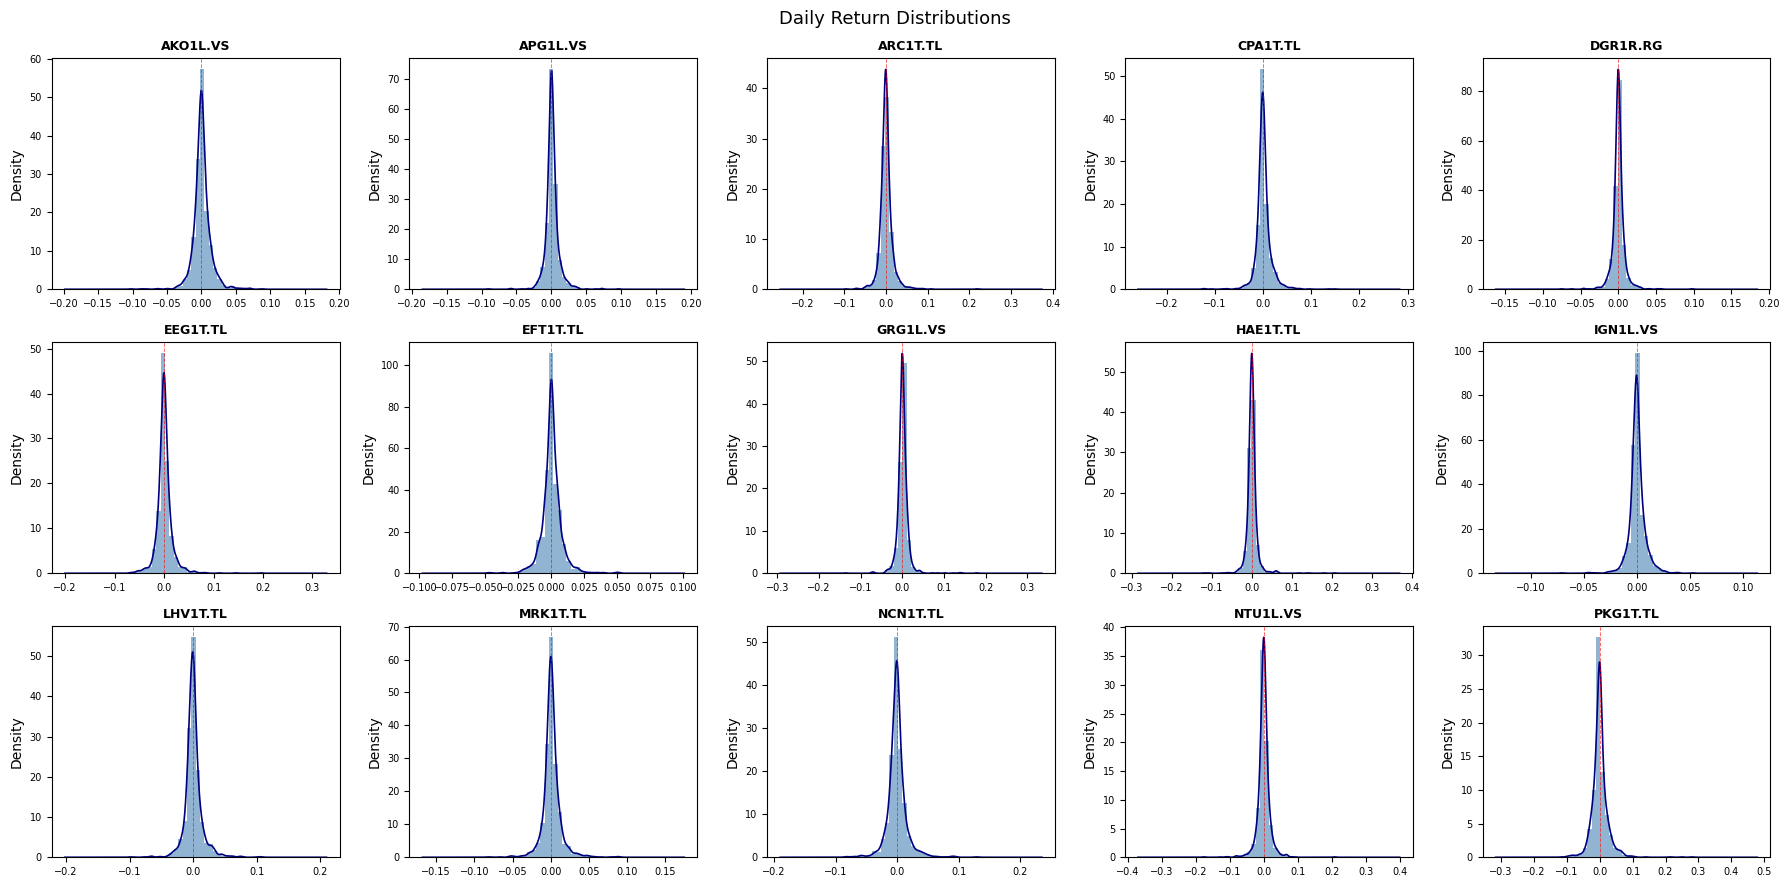

           Skew  Excess Kurt  Fat tails?  Skewed?
HAE1T.TL  3.536       54.435        True     True
GRG1L.VS  2.644       42.142        True     True
ARC1T.TL  2.436       31.004        True     True
DGR1R.RG  0.679       26.992        True    False
EEG1T.TL  2.355       24.490        True     True
NTU1L.VS -0.079       23.552        True    False
PKG1T.TL  2.293       22.958        True     True
APG1L.VS  0.870       19.933        True    False
CPA1T.TL  0.532       17.970        True    False
IGN1L.VS -0.473       12.046        True    False
MRK1T.TL  0.681       11.516        True    False
LHV1T.TL  0.832       11.252        True    False
AKO1L.VS -0.038       10.945        True    False
NCN1T.TL  0.941       10.509        True    False
EFT1T.TL  0.467        9.125        True    False


In [16]:
fig, axes = plt.subplots(3, 5, figsize=(18, 9))
axes = axes.flatten()

for i, ticker in enumerate(daily_returns.columns):
    ax = axes[i]
    data = daily_returns[ticker].dropna()
    ax.hist(data, bins=30, density=True, color="steelblue", alpha=0.6)
    data.plot.kde(ax=ax, color="navy", linewidth=1.2)
    ax.set_title(ticker, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
    ax.axvline(0, color="red", linewidth=0.7, linestyle="--", alpha=0.6)

fig.suptitle("Daily Return Distributions", fontsize=13)
plt.tight_layout()
plt.show()

skew = daily_returns.skew().round(3)
kurt = daily_returns.kurt().round(3)  # excess kurtosis (normal = 0)

shape_stats = pd.DataFrame({"Skew": skew, "Excess Kurt": kurt})
shape_stats["Fat tails?"] = shape_stats["Excess Kurt"] > 3
shape_stats["Skewed?"] = shape_stats["Skew"].abs() > 1
print(shape_stats.sort_values("Excess Kurt", ascending=False))

### 4c. Normality Test (Jarque-Bera)

In [17]:
from scipy import stats

jb_results = {}
for ticker in daily_returns.columns:
    data = daily_returns[ticker].dropna()
    stat, p = stats.jarque_bera(data)
    jb_results[ticker] = {"JB stat": round(stat, 1), "p-value": round(p, 4), "Normal?": p > 0.05}

jb_df = pd.DataFrame(jb_results).T.sort_values("JB stat", ascending=False)
print(jb_df)
print(f"\nTickers that pass normality (p>0.05): {jb_df[jb_df['Normal?'] == True].index.tolist()}")

           JB stat p-value Normal?
HAE1T.TL  162701.9     0.0   False
GRG1L.VS   95824.6     0.0   False
ARC1T.TL   53183.0     0.0   False
EEG1T.TL   33581.1     0.0   False
DGR1R.RG   32735.8     0.0   False
PKG1T.TL   29591.7     0.0   False
NTU1L.VS   29459.3     0.0   False
APG1L.VS   21260.2     0.0   False
CPA1T.TL   17491.0     0.0   False
IGN1L.VS    7751.2     0.0   False
MRK1T.TL    7256.7     0.0   False
LHV1T.TL    6981.6     0.0   False
AKO1L.VS    6359.5     0.0   False
NCN1T.TL    6150.4     0.0   False
EFT1T.TL    4539.2     0.0   False

Tickers that pass normality (p>0.05): []


### 4d. Monthly Return Distributions

          Ann. Return  Ann. Vol  Sharpe   Skew  Excess Kurt
APG1L.VS       0.2539    0.1779    1.43  0.796        2.643
MRK1T.TL       0.2622    0.2033    1.29  0.593        1.141
AKO1L.VS       0.1865    0.1970    0.95  0.194        0.368
GRG1L.VS       0.1790    0.2143    0.84  0.968        2.230
CPA1T.TL       0.1854    0.3402    0.55  1.839        5.948
DGR1R.RG       0.0591    0.1099    0.54 -1.009        2.780
EFT1T.TL       0.0531    0.0997    0.53  0.371        3.625
IGN1L.VS       0.0682    0.1360    0.50 -0.990        6.138
EEG1T.TL       0.1478    0.3133    0.47  4.329       27.162
LHV1T.TL       0.1192    0.2528    0.47  2.493       10.104
PKG1T.TL       0.1389    0.4371    0.32  1.614        3.486
ARC1T.TL       0.0722    0.2521    0.29  2.313        6.883
HAE1T.TL       0.0314    0.2001    0.16  2.430       13.802
NCN1T.TL      -0.0720    0.2526   -0.29  0.742        0.367
NTU1L.VS      -0.1658    0.3151   -0.53  0.220        0.977


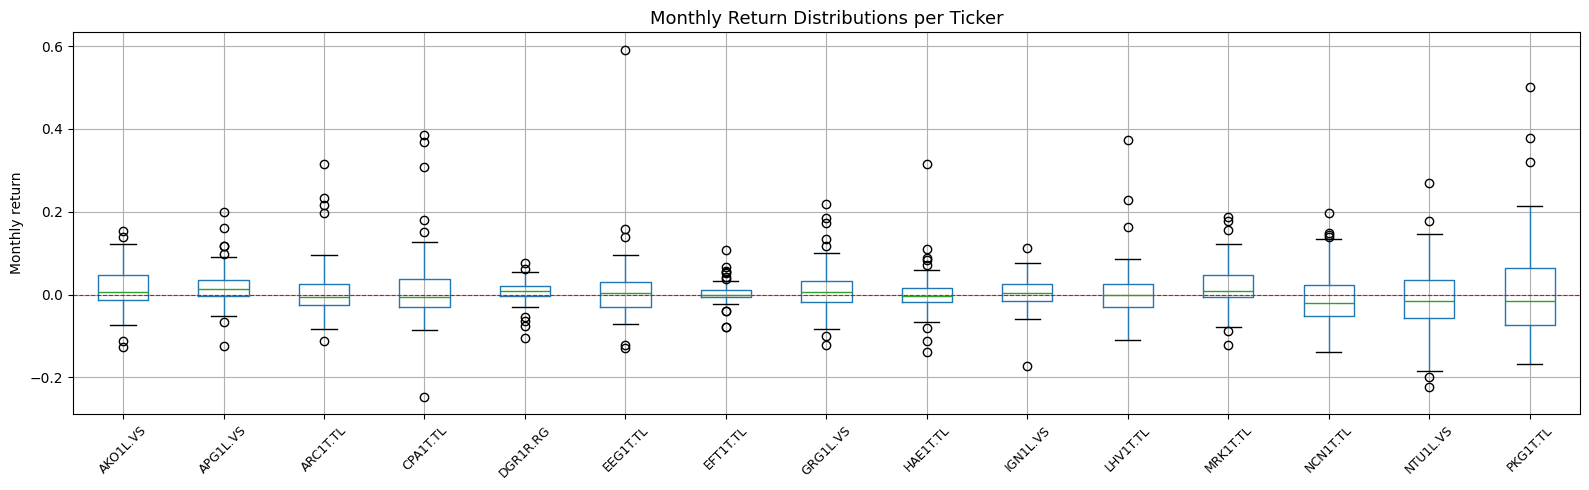

In [18]:
ann_return_m = monthly_returns.mean() * 12
ann_vol_m = monthly_returns.std() * np.sqrt(12)
sharpe_m = ann_return_m / ann_vol_m

summary_monthly = pd.DataFrame({
    "Ann. Return": ann_return_m.round(4),
    "Ann. Vol":    ann_vol_m.round(4),
    "Sharpe":      sharpe_m.round(2),
    "Skew":        monthly_returns.skew().round(3),
    "Excess Kurt": monthly_returns.kurt().round(3),
})
print(summary_monthly.sort_values("Sharpe", ascending=False))

# Box plot — visual comparison of monthly return spread and outliers
fig, ax = plt.subplots(figsize=(16, 5))
monthly_returns.boxplot(ax=ax, rot=45)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_title("Monthly Return Distributions per Ticker", fontsize=13)
ax.set_ylabel("Monthly return")
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

### 5a. Correlation Matrix (Monthly Returns)

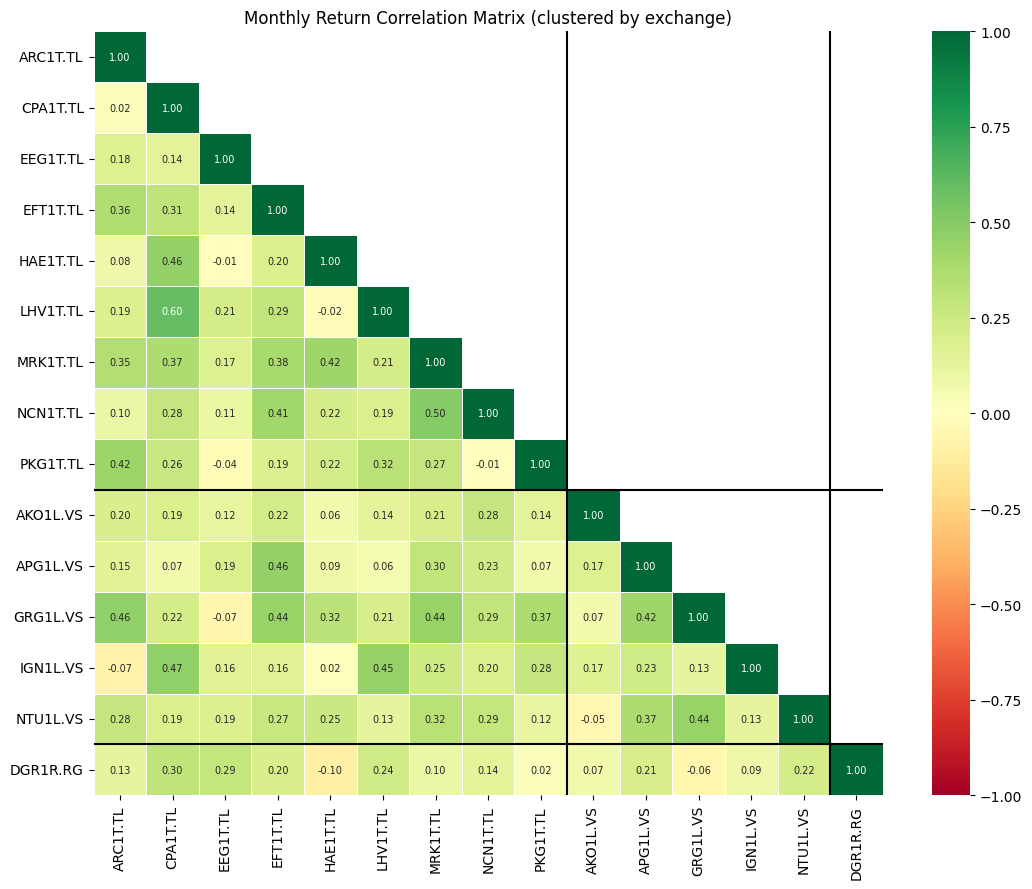

In [19]:
# Sort columns by exchange so clusters are visible on the heatmap
exchange_order = (
    [c for c in monthly_returns.columns if c.endswith(".TL")] +
    [c for c in monthly_returns.columns if c.endswith(".VS")] +
    [c for c in monthly_returns.columns if c.endswith(".RG")]
)
corr = monthly_returns[exchange_order].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # hide upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 7}
)
ax.set_title("Monthly Return Correlation Matrix (clustered by exchange)", fontsize=12)

# Draw lines separating exchanges
n_tl = sum(1 for c in exchange_order if c.endswith(".TL"))
n_vs = sum(1 for c in exchange_order if c.endswith(".VS"))
for pos in [n_tl, n_tl + n_vs]:
    ax.axhline(pos, color="black", linewidth=1.5)
    ax.axvline(pos, color="black", linewidth=1.5)

plt.tight_layout()
plt.show()

### 5b. Cross-Exchange vs Within-Exchange Correlation

In [20]:
tl = [c for c in monthly_returns.columns if c.endswith(".TL")]
vs = [c for c in monthly_returns.columns if c.endswith(".VS")]
rg = [c for c in monthly_returns.columns if c.endswith(".RG")]

def avg_corr(cols_a, cols_b, corr_matrix, within=False):
    """Average pairwise correlation between two groups (excludes diagonal if within=True)."""
    vals = []
    for a in cols_a:
        for b in cols_b:
            if within and a >= b:  # skip duplicate pairs and diagonal
                continue
            if a in corr_matrix.index and b in corr_matrix.columns:
                vals.append(corr_matrix.loc[a, b])
    return np.mean(vals) if vals else np.nan

results = {
    "Within TL":    avg_corr(tl, tl, corr, within=True),
    "Within VS":    avg_corr(vs, vs, corr, within=True),
    "TL vs VS":     avg_corr(tl, vs, corr),
    "TL vs RG":     avg_corr(tl, rg, corr),
    "VS vs RG":     avg_corr(vs, rg, corr),
}

print("Average pairwise correlations by exchange group:")
for k, v in results.items():
    print(f"  {k:<12} {v:.3f}")

Average pairwise correlations by exchange group:
  Within TL    0.236
  Within VS    0.208
  TL vs VS     0.218
  TL vs RG     0.147
  VS vs RG     0.106


### 5c. Rolling Correlation

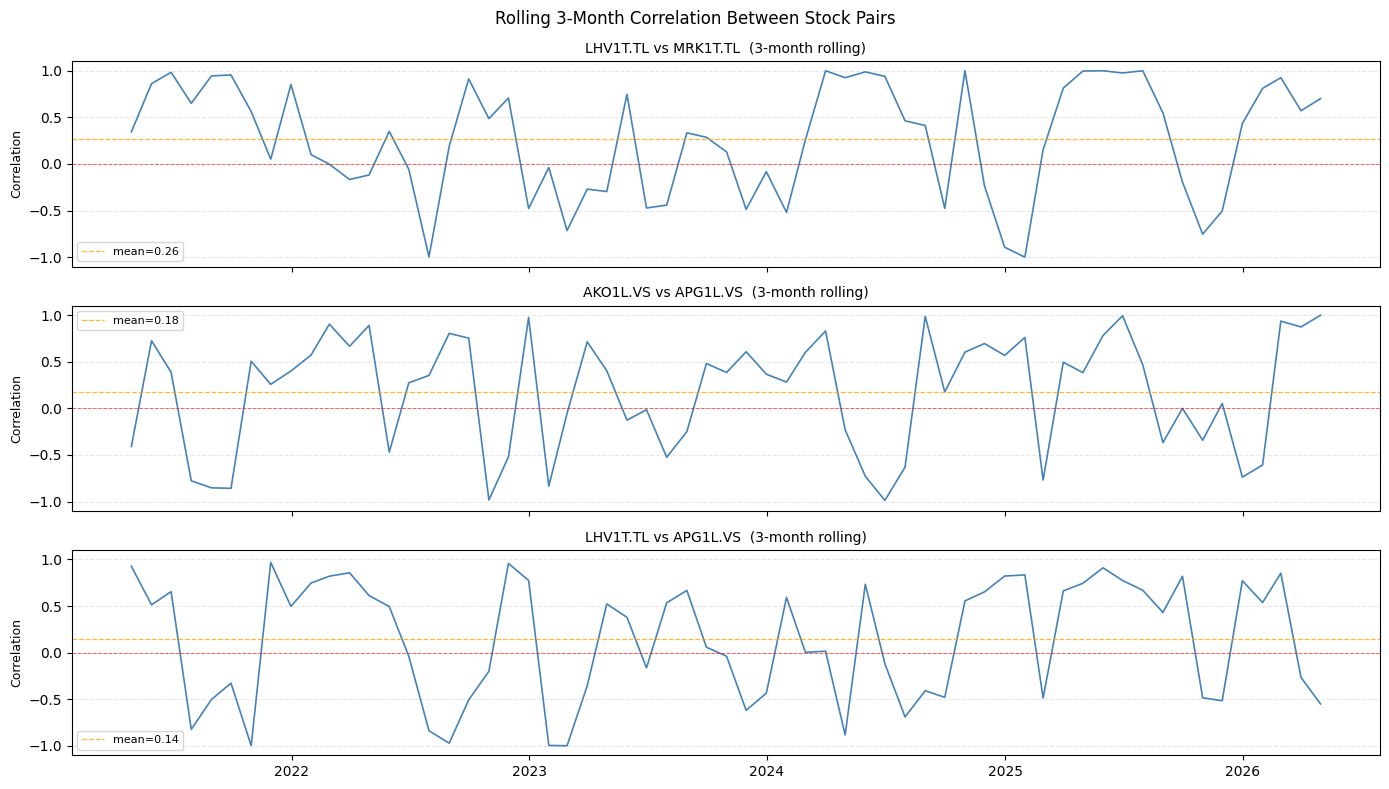

In [21]:
# 3 pairs: one within-TL, one within-VS, one cross-exchange
pairs = [
    ("LHV1T.TL", "MRK1T.TL"),   # within Tallinn
    ("AKO1L.VS", "APG1L.VS"),    # within Vilnius
    ("LHV1T.TL", "APG1L.VS"),    # cross-exchange TL vs VS
]

fig, axes = plt.subplots(len(pairs), 1, figsize=(14, 8), sharex=True)

for ax, (a, b) in zip(axes, pairs):
    rolling_corr = monthly_returns[a].rolling(3).corr(monthly_returns[b])
    ax.plot(rolling_corr.index, rolling_corr, linewidth=1.2, color="steelblue")
    ax.axhline(0, color="red", linewidth=0.7, linestyle="--", alpha=0.6)
    ax.axhline(rolling_corr.mean(), color="orange", linewidth=0.9,
               linestyle="--", alpha=0.8, label=f"mean={rolling_corr.mean():.2f}")
    ax.set_ylabel("Correlation", fontsize=9)
    ax.set_title(f"{a} vs {b}  (3-month rolling)", fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Rolling 3-Month Correlation Between Stock Pairs", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Return Autocorrelation

### 6a. Lag-1 Autocorrelation of Monthly Returns

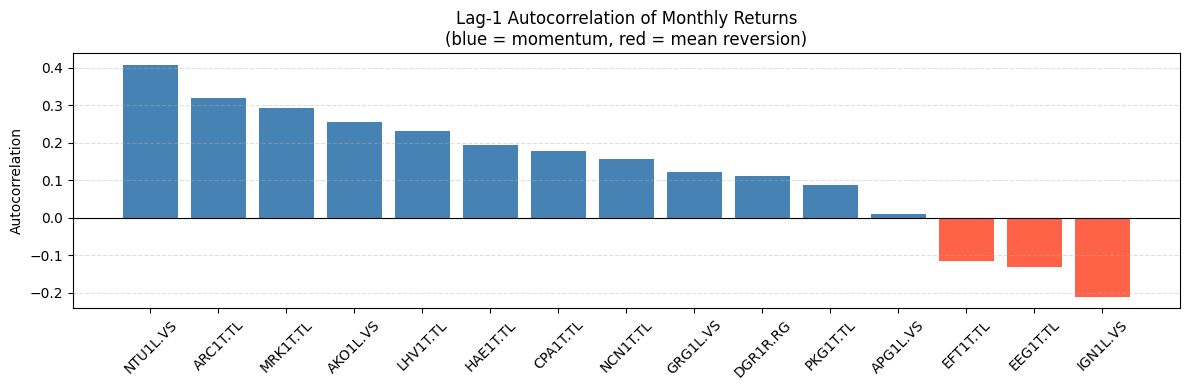

NTU1L.VS    0.408
ARC1T.TL    0.320
MRK1T.TL    0.291
AKO1L.VS    0.255
LHV1T.TL    0.231
HAE1T.TL    0.193
CPA1T.TL    0.179
NCN1T.TL    0.157
GRG1L.VS    0.122
DGR1R.RG    0.112
PKG1T.TL    0.088
APG1L.VS    0.010
EFT1T.TL   -0.114
EEG1T.TL   -0.130
IGN1L.VS   -0.210
dtype: float64

Momentum candidates  (autocorr > 0.1): ['NTU1L.VS', 'ARC1T.TL', 'MRK1T.TL', 'AKO1L.VS', 'LHV1T.TL', 'HAE1T.TL', 'CPA1T.TL', 'NCN1T.TL', 'GRG1L.VS', 'DGR1R.RG']
Mean reversion candidates (autocorr < -0.1): ['EFT1T.TL', 'EEG1T.TL', 'IGN1L.VS']


In [22]:
lag1 = monthly_returns.apply(lambda x: x.autocorr(lag=1)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["steelblue" if v > 0 else "tomato" for v in lag1]
ax.bar(lag1.index, lag1.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Lag-1 Autocorrelation of Monthly Returns\n(blue = momentum, red = mean reversion)", fontsize=12)
ax.set_ylabel("Autocorrelation")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(lag1.round(3))
print(f"\nMomentum candidates  (autocorr > 0.1): {lag1[lag1 > 0.1].index.tolist()}")
print(f"Mean reversion candidates (autocorr < -0.1): {lag1[lag1 < -0.1].index.tolist()}")

### 6b. Partial Autocorrelation (PACF)

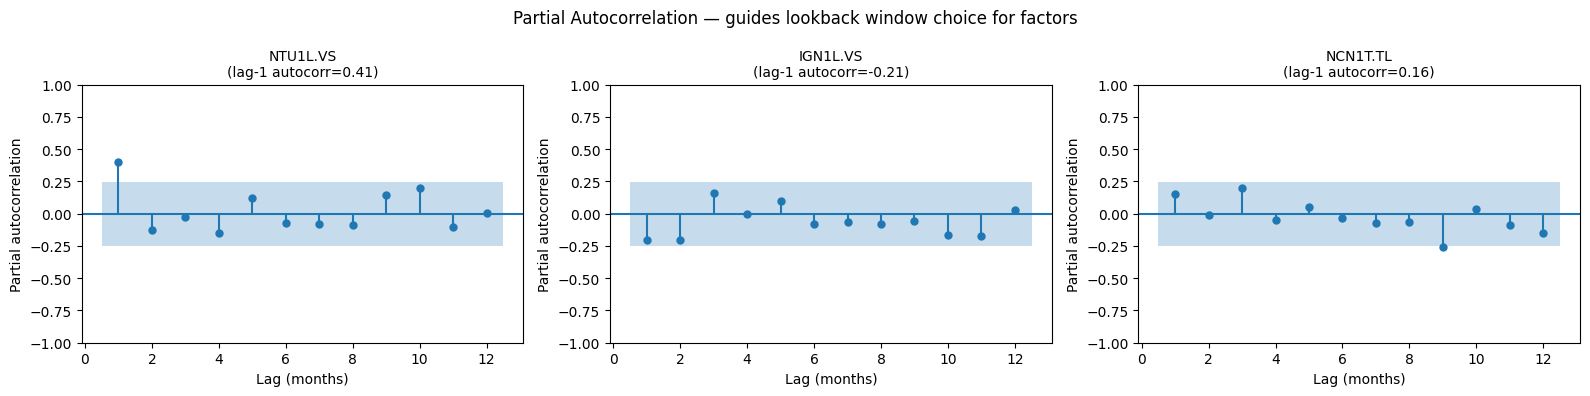

In [23]:
from statsmodels.graphics.tsaplots import plot_pacf

# Pick top momentum, top mean-reversion, and one middle ticker
pacf_tickers = [lag1.index[0], lag1.index[-1], lag1.index[len(lag1) // 2]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, ticker in zip(axes, pacf_tickers):
    data = monthly_returns[ticker].dropna()
    plot_pacf(data, lags=12, ax=ax, method="ywm", alpha=0.05, zero=False)
    ax.set_title(f"{ticker}\n(lag-1 autocorr={lag1[ticker]:.2f})", fontsize=10)
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Partial autocorrelation")

fig.suptitle("Partial Autocorrelation — guides lookback window choice for factors", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Volatility Analysis

### 7a. Rolling Volatility (21-day)

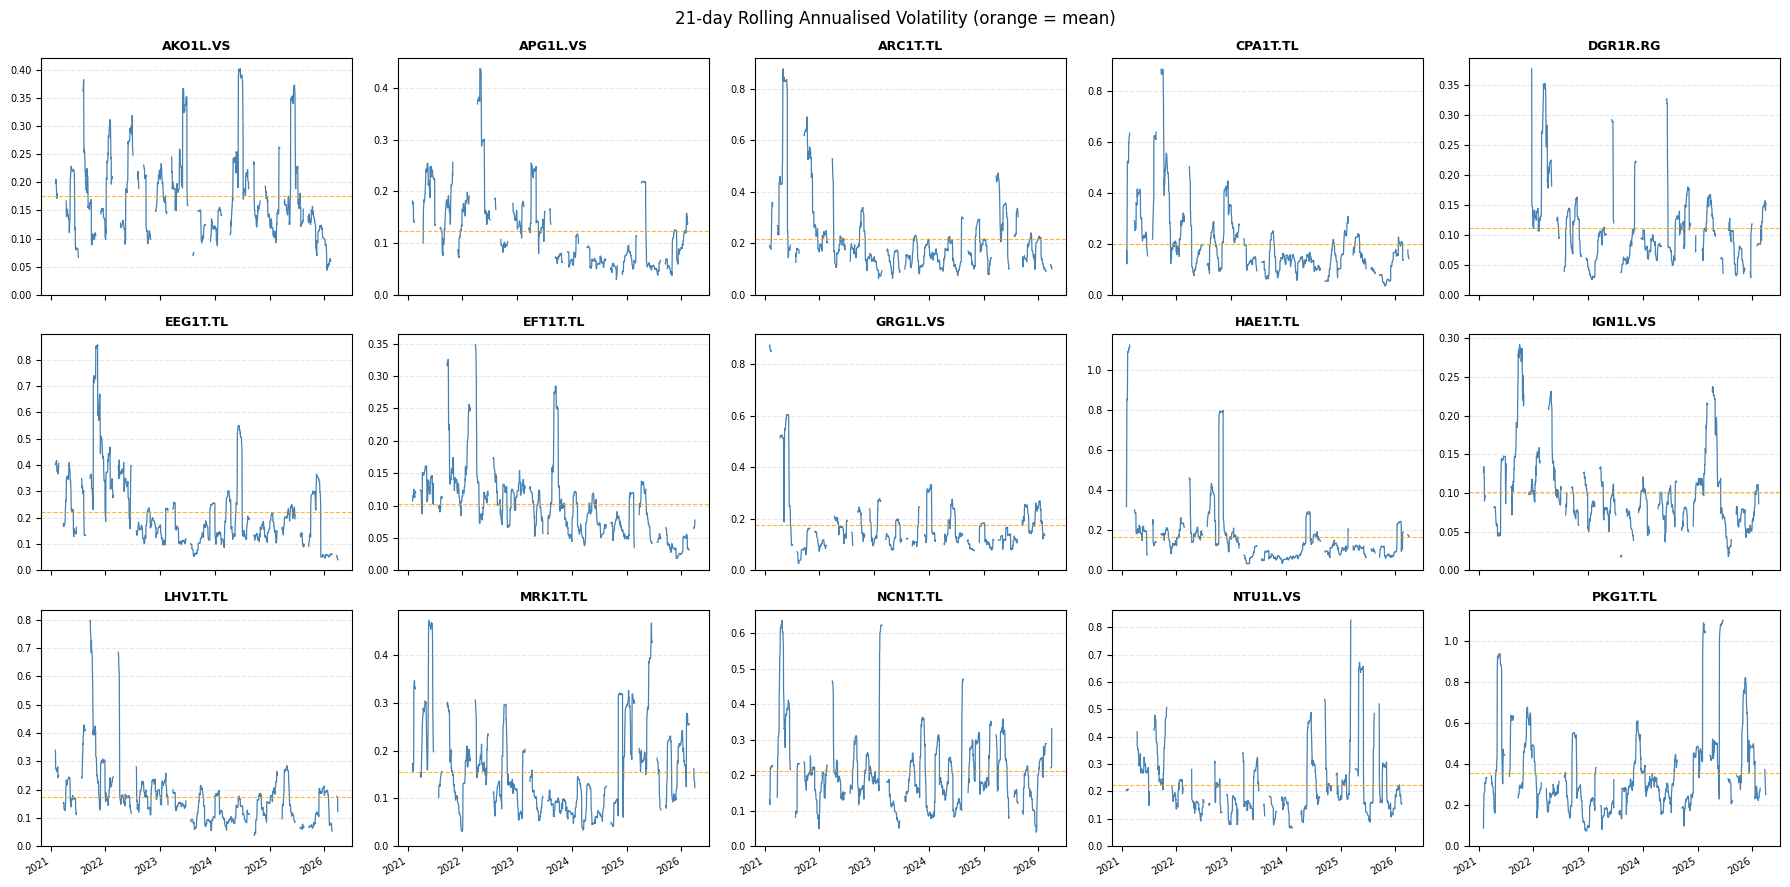

In [24]:
rolling_vol = daily_returns.rolling(21).std() * np.sqrt(252)  # annualised

fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(rolling_vol.columns):
    ax = axes[i]
    ax.plot(rolling_vol.index, rolling_vol[ticker], linewidth=0.9, color="steelblue")
    ax.axhline(rolling_vol[ticker].mean(), color="orange", linewidth=0.8,
               linestyle="--", alpha=0.8)
    ax.set_title(ticker, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.set_ylim(0, None)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("21-day Rolling Annualised Volatility (orange = mean)", fontsize=12)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

### 7b. Volatility Ranking

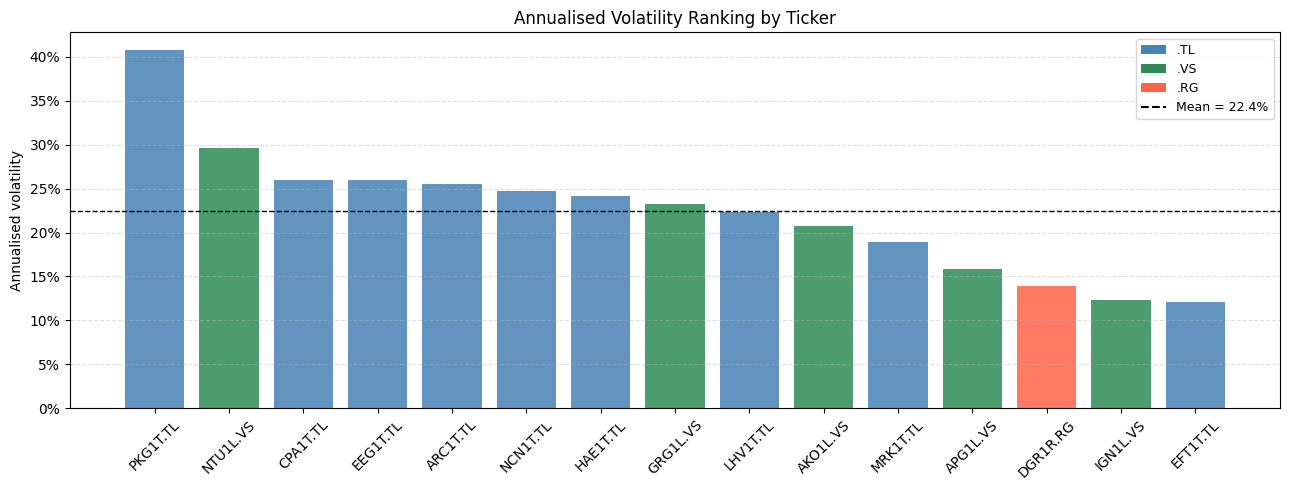

PKG1T.TL    0.4077
NTU1L.VS    0.2965
CPA1T.TL    0.2599
EEG1T.TL    0.2595
ARC1T.TL    0.2557
NCN1T.TL    0.2469
HAE1T.TL    0.2411
GRG1L.VS    0.2322
LHV1T.TL    0.2230
AKO1L.VS    0.2080
MRK1T.TL    0.1898
APG1L.VS    0.1584
DGR1R.RG    0.1386
IGN1L.VS    0.1231
EFT1T.TL    0.1209
dtype: float64


In [25]:
avg_vol = (daily_returns.std() * np.sqrt(252)).sort_values(ascending=False)

exchange_colors = {".TL": "steelblue", ".VS": "seagreen", ".RG": "tomato"}
colors = [exchange_colors[t[-3:]] for t in avg_vol.index]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(avg_vol.index, avg_vol.values, color=colors, alpha=0.85)
ax.axhline(avg_vol.mean(), color="black", linewidth=1, linestyle="--",
           label=f"Mean vol = {avg_vol.mean():.1%}")
ax.set_title("Annualised Volatility Ranking by Ticker", fontsize=12)
ax.set_ylabel("Annualised volatility")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)

# Exchange legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in exchange_colors.items()]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color="black", linestyle="--",
          label=f"Mean = {avg_vol.mean():.1%}")], fontsize=9)

plt.tight_layout()
plt.show()

print(avg_vol.round(4))

### 7c. Vol of Vol

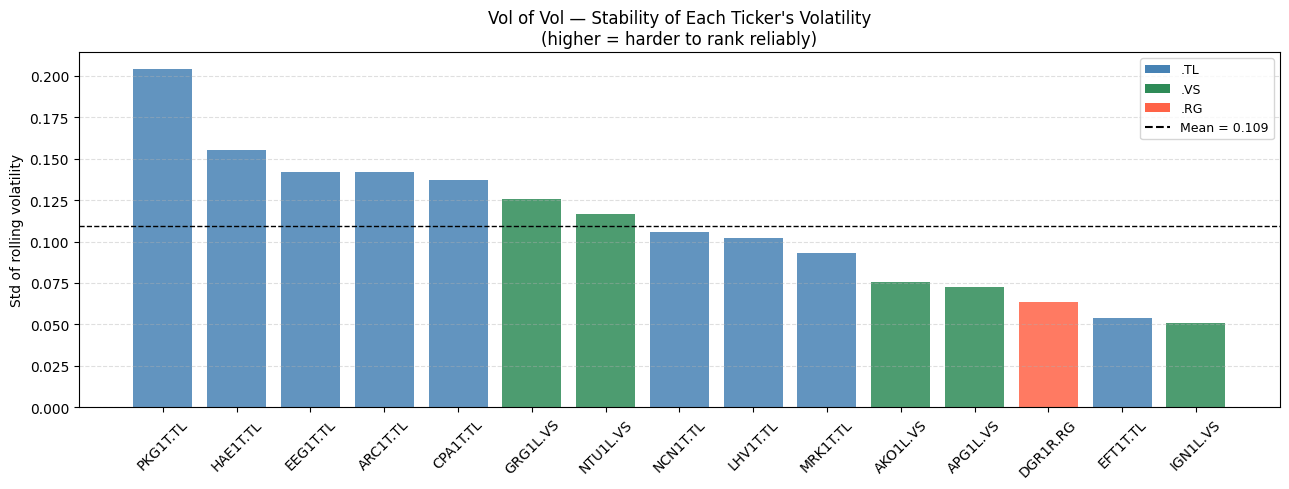

          Avg Ann. Vol  Vol of Vol  Unstable?
PKG1T.TL        0.4077      0.2042       True
HAE1T.TL        0.2411      0.1556       True
EEG1T.TL        0.2595      0.1423       True
ARC1T.TL        0.2557      0.1419       True
CPA1T.TL        0.2599      0.1371       True
GRG1L.VS        0.2322      0.1258       True
NTU1L.VS        0.2965      0.1168       True
NCN1T.TL        0.2469      0.1055      False
LHV1T.TL        0.2230      0.1019      False
MRK1T.TL        0.1898      0.0931      False
AKO1L.VS        0.2080      0.0758      False
APG1L.VS        0.1584      0.0725      False
DGR1R.RG        0.1386      0.0632      False
EFT1T.TL        0.1209      0.0536      False
IGN1L.VS        0.1231      0.0507      False


In [26]:
vol_of_vol = rolling_vol.std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colors = [exchange_colors[t[-3:]] for t in vol_of_vol.index]
ax.bar(vol_of_vol.index, vol_of_vol.values, color=colors, alpha=0.85)
ax.axhline(vol_of_vol.mean(), color="black", linewidth=1, linestyle="--",
           label=f"Mean = {vol_of_vol.mean():.3f}")
ax.set_title("Vol of Vol — Stability of Each Ticker's Volatility\n(higher = harder to rank reliably)", fontsize=12)
ax.set_ylabel("Std of rolling volatility")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color="black", linestyle="--",
          label=f"Mean = {vol_of_vol.mean():.3f}")], fontsize=9)
plt.tight_layout()
plt.show()

vol_summary = pd.DataFrame({
    "Avg Ann. Vol":  avg_vol.round(4),
    "Vol of Vol":    vol_of_vol.round(4),
    "Unstable?":     vol_of_vol > vol_of_vol.mean(),
})
print(vol_summary.sort_values("Vol of Vol", ascending=False))